In [20]:
import matplotlib.pyplot as plt
import numpy as np
import dsharp_opac as do
import pandas as pd

prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/npz_files/"

# Load in Zhang data

In [2]:
Zhang_prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/npz_files/"

Zhang_files = {
    '1': "dsharp_p0.00_smooth_extrapol.npz",
    '0.3': "dsharp_p0.70_smooth_extrapol.npz",
    '0.1':"dsharp_p0.90_smooth_extrapol.npz"    
}

Zhang_idx = ['1', '0.3', '0.1']

Zhang_data = {}

for idx in Zhang_idx:
    Zhang_data[idx] = np.load(Zhang_prefix + Zhang_files[idx])

## Compare values within Zhang data

In [3]:
variables = ["a", "lam", "k_abs", "k_sca", "g", "rho_s", "S1", "S2", "theta"]

for v in variables:
    print(f"\nChecking {v}:")
    for i in range(len(Zhang_idx)):
        for j in range(i + 1, len(Zhang_idx)):
            idx1 = Zhang_idx[i]
            idx2 = Zhang_idx[j]

            same = np.array_equal(Zhang_data[idx1][v], Zhang_data[idx2][v])
            print(f"f = {idx1} vs {idx2}: {same}")


Checking a:
f = 1 vs 0.3: True
f = 1 vs 0.1: True
f = 0.3 vs 0.1: True

Checking lam:
f = 1 vs 0.3: True
f = 1 vs 0.1: True
f = 0.3 vs 0.1: True

Checking k_abs:
f = 1 vs 0.3: False
f = 1 vs 0.1: False
f = 0.3 vs 0.1: False

Checking k_sca:
f = 1 vs 0.3: False
f = 1 vs 0.1: False
f = 0.3 vs 0.1: False

Checking g:
f = 1 vs 0.3: False
f = 1 vs 0.1: False
f = 0.3 vs 0.1: False

Checking rho_s:
f = 1 vs 0.3: False
f = 1 vs 0.1: False
f = 0.3 vs 0.1: False

Checking S1:
f = 1 vs 0.3: False
f = 1 vs 0.1: False
f = 0.3 vs 0.1: False

Checking S2:
f = 1 vs 0.3: False
f = 1 vs 0.1: False
f = 0.3 vs 0.1: False

Checking theta:
f = 1 vs 0.3: True
f = 1 vs 0.1: True
f = 0.3 vs 0.1: True


In [4]:
amin = 1e-5
amax = 1e4
na = 258

a_grid_cm = np.geomspace(amin, amax, na)

np.sum(a_grid_cm - Zhang_data['1']['a'])

8.881784197001252e-16

In [5]:
lam_min = 1e-5
lam_max = 10
nl = 210

lam_grid_cm = np.geomspace(lam_min, lam_max, nl)

np.sum(lam_grid_cm - Zhang_data['1']['lam'])

0.0

## Zhang data at specifc wavelengths

In [6]:
obs_wavs = np.array([0.8740e-1, 1.287e-1, 2.141e-1, 7.889e-1])

In [7]:
# Loop over wavelengths
for iw, wav in enumerate(obs_wavs):
    print(f'Observing Wavelength should be: {wav}')

    # Loop over f values
    for f_idx in Zhang_idx:
        
        Zhang_f = Zhang_data[f_idx]
        lam_idx = Zhang_f['lam'].searchsorted(wav)
        
        print(f"     f = {f_idx} and closest lam = {Zhang_f['lam'][lam_idx]} at idx of {lam_idx}")
    
# This shows us that no matter what f value, the closest wavelength is always the same
# This makes sense since lambda is the same for all f values 

Observing Wavelength should be: 0.0874
     f = 1 and closest lam = 0.09156352169090812 at idx of 138
     f = 0.3 and closest lam = 0.09156352169090812 at idx of 138
     f = 0.1 and closest lam = 0.09156352169090812 at idx of 138
Observing Wavelength should be: 0.1287
     f = 1 and closest lam = 0.1361354689969627 at idx of 144
     f = 0.3 and closest lam = 0.1361354689969627 at idx of 144
     f = 0.1 and closest lam = 0.1361354689969627 at idx of 144
Observing Wavelength should be: 0.2141
     f = 1 and closest lam = 0.21623611482262062 at idx of 151
     f = 0.3 and closest lam = 0.21623611482262062 at idx of 151
     f = 0.1 and closest lam = 0.21623611482262062 at idx of 151
Observing Wavelength should be: 0.7889
     f = 1 and closest lam = 0.8111308307896873 at idx of 171
     f = 0.3 and closest lam = 0.8111308307896873 at idx of 171
     f = 0.1 and closest lam = 0.8111308307896873 at idx of 171


In [8]:
wavelength_indices = {
    '0.87': 138,
    '1.3': 144,
    '2.1': 151,
    '7.9': 171,
}

Zhang_data_wavelength = {}

for wav_name, lam_idx in wavelength_indices.items():
    Zhang_data_wavelength[wav_name] = {}

    for f_idx in Zhang_idx:
        Zhang_f = Zhang_data[f_idx]

        Zhang_data_wavelength[wav_name][f_idx] = {
            'a'     : Zhang_f['a'],
            'lam'   : Zhang_f['lam'][lam_idx],
            'k_abs' : Zhang_f['k_abs'][:, lam_idx],
            'k_sca' : Zhang_f['k_sca'][:, lam_idx],
            'g'     : Zhang_f['g'][:, lam_idx],
            'rho_s' : Zhang_f['rho_s'],
            'S1'    : Zhang_f['S1'][:, lam_idx],
            'S2'    : Zhang_f['S2'][:, lam_idx],
            'theta' : Zhang_f['theta'],
        }

# Load in my data files

In [9]:
MY_prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

MY_wavelength_loc = {
    '0.87' :  "0.87mm_closest/",
    '1.3'  :  "1.3mm_closest/",
    '2.1'  :  "2.14mm_closest/",
    '7.9'  :  "7.89mm_closest/",
}



MY_files = {
    '1'   : "dsharp_results_ff_1.00_smoothed_extrapol.npz",
    '0.3' : "dsharp_results_ff_0.30_smoothed_extrapol.npz",
    '0.1' : "dsharp_results_ff_0.30_smoothed_extrapol.npz",   
}


MY_data = {}

for wav in MY_wavelength_loc:
    MY_data[wav] = {}

    for f in MY_files:
        filename = (MY_prefix + MY_wavelength_loc[wav] + MY_files[f])

        MY_data[wav][f] = np.load(filename)

# Compare Zhang to mine at a specifc wavelength and lambda

## Find the actual wavelengths Zhang is using

# $\lambda$ = 0.87 mm

In [10]:
ZD = Zhang_data_wavelength['0.87']['1']

MD = MY_data['0.87']['1']


for var in variables:
    print(var)
    print("  ZD:", ZD[var].shape)
    print("  MD:", MD[var].shape)
    
    z = ZD[var]
    m = MD[var]

#     print(f"\n{var}")
    print(f"  equal?      {np.array_equal(z, m)}")
    print(f"  allclose?   {np.allclose(z, m)}")
    print(f"  max |Δ|     {np.max(np.abs(z - m))}")
    print(f"  mean |Δ|    {np.mean(np.abs(z - m))}")
    print(' ')

a
  ZD: (258,)
  MD: (258,)
  equal?      False
  allclose?   True
  max |Δ|     8.881784197001252e-16
  mean |Δ|    3.4425520143415706e-18
 
lam
  ZD: ()
  MD: ()
  equal?      True
  allclose?   True
  max |Δ|     0.0
  mean |Δ|    0.0
 
k_abs
  ZD: (258,)
  MD: (258,)
  equal?      False
  allclose?   True
  max |Δ|     4.4177412181767295e-06
  mean |Δ|    1.1594333621039444e-07
 
k_sca
  ZD: (258,)
  MD: (258,)
  equal?      False
  allclose?   True
  max |Δ|     2.1184258756079544e-05
  mean |Δ|    4.670748597931104e-07
 
g
  ZD: (258,)
  MD: (258,)
  equal?      False
  allclose?   True
  max |Δ|     1.4164519198667236e-06
  mean |Δ|    1.4115185478210514e-07
 
rho_s
  ZD: ()
  MD: ()
  equal?      True
  allclose?   True
  max |Δ|     0.0
  mean |Δ|    0.0
 
S1
  ZD: (258, 5)
  MD: (258, 5)
  equal?      False
  allclose?   False
  max |Δ|     33.40877747604322
  mean |Δ|    0.2274749304545274
 
S2
  ZD: (258, 5)
  MD: (258, 5)
  equal?      False
  allclose?   False
  max |Δ|  

In [22]:
max_diff_df = pd.DataFrame(index=variables, columns=Zhang_idx)

for f in Zhang_idx:
    ZD = Zhang_data_wavelength['0.87'][f]
    MD = MY_data['0.87'][f]

    for var in variables:
        max_diff_df.loc[var, f] = np.max(np.abs(ZD[var] - MD[var]))

max_diff_df

,1,0.3,0.1
a,0.0,0.0,0.0
lam,0.0,0.0,0.0
k_abs,0.000004,0.00002,0.378827
k_sca,0.000021,0.00002,39.662376
g,0.000001,0.000007,0.251841
rho_s,0.0,0.0,0.335056
S1,33.408777,91.922026,15190739440.843941
S2,23.161324,91.922026,15190739440.843941
theta,0.0,0.0,0.0


# $\lambda$ = 1.3 mm

In [23]:
max_diff_df = pd.DataFrame(index=variables, columns=Zhang_idx)

for f in Zhang_idx:
    ZD = Zhang_data_wavelength['1.3'][f]
    MD = MY_data['1.3'][f]

    for var in variables:
        max_diff_df.loc[var, f] = np.max(np.abs(ZD[var] - MD[var]))

max_diff_df

,1,0.3,0.1
a,0.0,0.0,0.0
lam,0.0,0.0,0.0
k_abs,0.000002,0.000018,0.199397
k_sca,0.000006,0.000017,26.742629
g,0.000002,0.00001,0.254107
rho_s,0.0,0.0,0.335056
S1,20.221662,168.834785,15391298682.48745
S2,20.221662,168.834785,15391298682.48745
theta,0.0,0.0,0.0


# $\lambda$ = 2.14 mm

In [27]:
max_diff_df = pd.DataFrame(index=variables, columns=Zhang_idx)

for f in Zhang_idx:
    ZD = Zhang_data_wavelength['2.1'][f]
    MD = MY_data['2.1'][f]

    for var in variables:
        max_diff_df.loc[var, f] = np.max(np.abs(ZD[var] - MD[var]))

max_diff_df

,1,0.3,0.1
a,0.0,0.0,0.0
lam,0.0,0.0,0.0
k_abs,0.000001,0.000017,0.088797
k_sca,0.000011,0.000017,16.819318
g,0.000001,0.00002,0.26038
rho_s,0.0,0.0,0.335056
S1,24.288234,103.748753,13663486935.769218
S2,24.288234,103.748753,13663486935.769218
theta,0.0,0.0,0.0


# $\lambda$ = 7.89 mm

In [25]:
max_diff_df = pd.DataFrame(index=variables, columns=Zhang_idx)

for f in Zhang_idx:
    ZD = Zhang_data_wavelength['7.9'][f]
    MD = MY_data['7.9'][f]

    for var in variables:
        max_diff_df.loc[var, f] = np.max(np.abs(ZD[var] - MD[var]))

max_diff_df

,1,0.3,0.1
a,0.0,0.0,0.0
lam,0.0,0.0,0.0
k_abs,0.000001,0.000007,0.008571
k_sca,0.000001,0.000007,4.493893
g,0.000014,0.000062,0.27009
rho_s,0.0,0.0,0.335056
S1,34.639775,15.822551,68023.368777
S2,30.118798,15.822551,68023.368777
theta,0.0,0.0,0.0


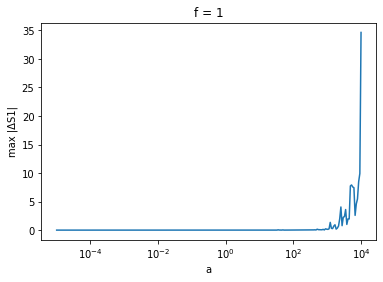

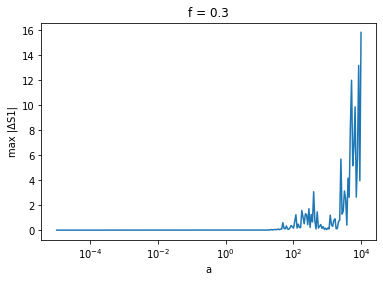

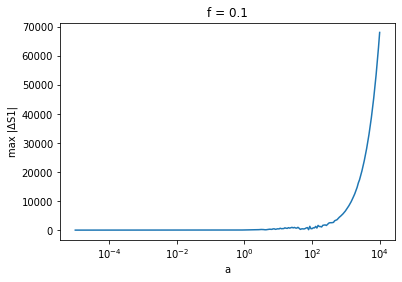

In [28]:
for f in Zhang_idx:
    ZD = Zhang_data_wavelength['7.9'][f]
    MD = MY_data['7.9'][f]

    diff = np.max(np.abs(ZD['S1'] - MD['S1']), axis=1)

    plt.figure()
    plt.semilogx(ZD['a'], diff)
    plt.title(f"f = {f}")
    plt.xlabel("a")
    plt.ylabel("max |ΔS1|")
    plt.show()